In [ ]:
import clip
import torch
from PIL import Image
import numpy as np
import gym
from stable_baselines3 import DQN, SAC
from stable_baselines3.common.vec_env import DummyVecEnv
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

c:\Users\Asus\anaconda3\envs\rl\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: [WinError 127] The specified procedure could not be found
  warn(f"Failed to load image Python extension: {e}")


In [ ]:
def load_clip_model(device='cpu'):
    
    clip_model, preprocess = clip.load("ViT-L/14", device=device)
    return clip_model, preprocess

def compute_embeddings(clip_model, preprocess, inputs, device='cpu'):
    
    with torch.no_grad():
        if isinstance(inputs, list): 
            embeddings = clip_model.encode_text(clip.tokenize(inputs).to(device))
        else:  
            img = preprocess(inputs).unsqueeze(0).to(device)
            embeddings = clip_model.encode_image(img)
    return embeddings


In [ ]:
def compute_cosine_reward(state, task_description, clip_model, preprocess, device='cpu'):

    img = Image.fromarray((state * 255).astype(np.uint8))  

    image_features = compute_embeddings(clip_model, preprocess, img, device=device)
    text_features = compute_embeddings(clip_model, preprocess, [task_description], device=device)

    final_reward = torch.cosine_similarity(image_features, text_features).item()
    return final_reward

def compute_regularized_clip_reward(state, task_description, clip_model, preprocess, baseline_embedding, alpha=1.0, device='cpu'):

    img = Image.fromarray((state * 255).astype(np.uint8))  

    state_embedding = compute_embeddings(clip_model, preprocess, img, device=device)
    task_embedding = compute_embeddings(clip_model, preprocess, [task_description], device=device)
    
    projection_vector = task_embedding - baseline_embedding
    projection = (torch.dot(state_embedding.squeeze(), projection_vector.squeeze()) /
                  torch.dot(projection_vector.squeeze(), projection_vector.squeeze())) * projection_vector
    regularized_embedding = alpha * projection + (1 - alpha) * state_embedding

    final = 1 - 0.5 * torch.norm(regularized_embedding - task_embedding).item() ** 2
    return final


In [ ]:
class ClipRewardEnv(gym.Env):
    def __init__(self, env, task_description, clip_model, preprocess, reward_type='cosine', baseline_embedding=None, alpha=1.0, device='cpu'):
        super(ClipRewardEnv, self).__init__()
        self.env = env
        self.task_description = task_description
        self.clip_model = clip_model
        self.preprocess = preprocess
        self.reward_type = reward_type
        self.baseline_embedding = baseline_embedding
        self.alpha = alpha
        self.device = device

        self.observation_space = self.env.observation_space
        
        self.action_space = self.env.action_space

    def reset(self):
        state, _ = self.env.reset()
        return np.array(state, dtype=np.float32)

    def step(self, action):
        state, _, terminated, truncated, info = self.env.step(action)
        if self.reward_type == 'cosine':
            reward = compute_cosine_reward(state, self.task_description, self.clip_model, self.preprocess, device=self.device)
        else:
            reward = compute_regularized_clip_reward(state, self.task_description, self.clip_model, self.preprocess, self.baseline_embedding, alpha=self.alpha, device=self.device)
        done = terminated or truncated
        return np.array(state, dtype=np.float32), reward, done, info


In [ ]:
def train_agent(env, algo='DQN', total_timesteps=10000):
    
    if algo == 'DQN':
        model = DQN("MlpPolicy", env, verbose=1)
    elif algo == 'SAC':
        model = SAC("MlpPolicy", env, verbose=1)
    model.learn(total_timesteps=total_timesteps)
    return model

def test_agent(model, env, episodes=10):
    for ep in range(episodes):
        obs = env.reset()
        done = False
        while not done:
            action, _ = model.predict(obs)
            obs, reward, done, info = env.step(action)


Training

In [ ]:
# Load CLIP 
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, preprocess = load_clip_model(device)

# Task and baseline prompt
task_description = "pole vertically upright on top of the cart"
baseline_description = "pole and cart"

baseline_embedding = compute_embeddings(clip_model, preprocess, [baseline_description], device=device)

#CartPole env
env = gym.make("CartPole-v1")
clip_reward_env = ClipRewardEnv(env, task_description, clip_model, preprocess, reward_type='regularized', baseline_embedding=baseline_embedding, alpha=1.0, device=device)
vec_env = DummyVecEnv([lambda: clip_reward_env])


100%|███████████████████████████████████████| 890M/890M [00:59<00:00, 15.7MiB/s]
c:\Users\Asus\anaconda3\envs\rl\lib\site-packages\stable_baselines3\common\vec_env\patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [ ]:
# Training
algo = 'DQN'  
total_timesteps = 10000
model = train_agent(vec_env, algo=algo, total_timesteps=total_timesteps)


Using cpu device


c:\Users\Asus\anaconda3\envs\rl\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


----------------------------------
| rollout/            |          |
|    exploration_rate | 0.932    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1        |
|    time_elapsed     | 71       |
|    total_timesteps  | 72       |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.819    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1        |
|    time_elapsed     | 186      |
|    total_timesteps  | 190      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 97.3     |
|    n_updates        | 22       |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.741    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 1        |
|    time_elapsed   

Testing

In [ ]:
pole_angles = []
rewards = []
obs = vec_env.reset()


for _ in range(1000):  
    action, _ = model.predict(obs)
    obs, reward, done, info = vec_env.step(action)

    
    pole_angle = float(obs[0][2])  
    pole_angles.append(pole_angle)

    
    rewards.append(float(reward[0]))  

    if done[0]: 
        obs = vec_env.reset()


pole_angles = np.array(pole_angles)
rewards = np.array(rewards)

# Normalizing the reward
normalized_rewards = (rewards - rewards.min()) / (rewards.max() - rewards.min())


In [ ]:
# Checking the minimim and maximum pole angle
print(f"Min Pole Angle: {pole_angles.min()}, Max Pole Angle: {pole_angles.max()}")


Min Pole Angle: -0.050014927983284, Max Pole Angle: 0.20895887911319733


In [10]:
pole_angles

array([-1.53152831e-02, -8.72128736e-03,  3.62899108e-03,  2.17777379e-02,
        4.58029099e-02,  7.58166388e-02,  1.11962855e-01,  1.54414013e-01,
        2.03366637e-01,  5.00983791e-03,  4.38306145e-02,  4.96009290e-02,
        6.14948049e-02,  7.95463845e-02,  1.03825182e-01,  1.34434208e-01,
        1.71507210e-01,  4.10545506e-02, -2.90343463e-02, -2.25614887e-02,
       -1.04208887e-02,  7.42955459e-03,  3.10677793e-02,  4.88991067e-02,
        7.27761313e-02,  1.02805153e-01,  1.39123946e-01,  1.81898251e-01,
       -1.09972758e-02,  6.51811203e-03,  1.30692255e-02,  2.55149659e-02,
        4.38961089e-02,  6.82890788e-02,  9.88041982e-02,  1.35583147e-01,
        1.78795382e-01,  3.84407938e-02, -1.70397162e-02, -1.08869448e-02,
        1.01104006e-03,  1.86937004e-02,  4.22363728e-02,  7.17487261e-02,
        1.07372478e-01,  1.49278179e-01,  1.97660953e-01,  2.65000071e-02,
        2.94872038e-02,  3.51839811e-02,  4.69174646e-02,  6.47220537e-02,
        8.86677355e-02,  

In [ ]:
# Plot Reward vs Pole Angle plot
plt.figure(figsize=(8, 6))
plt.scatter(pole_angles, normalized_rewards, s=10, alpha=1.0, color='blue', label='Reward')
plt.axvline(x=0, color='black', linestyle='--', label='Pole Upright')
plt.xlabel("Pole Angle (radians)")
plt.ylabel("Reward (rescaled)")
plt.title("Reward vs Pole Angle")
plt.legend()
plt.grid()
plt.show()


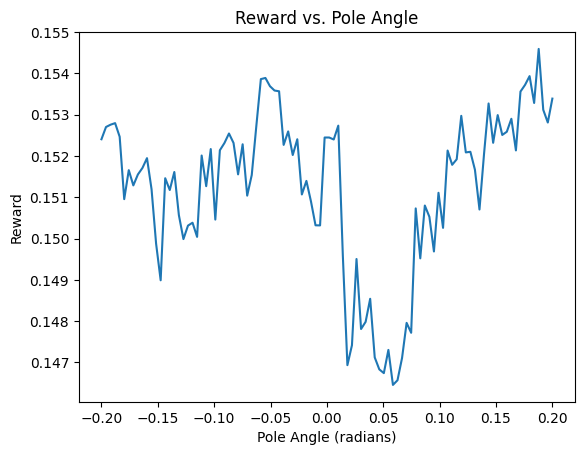

In [ ]:
# Below code is just checking wether, clip model working as expected or not
pole_angles = np.linspace(-0.2, 0.2, num=100)  
rewards = []


for angle in pole_angles:
   
    synthetic_state = np.array([0.0, 0.0, angle, 0.0]) 
    
 
    reward = compute_cosine_reward(
        synthetic_state, 
        task_description="pole vertically upright on top of the cart", 
        clip_model=clip_model, 
        preprocess=preprocess, 
        device=device
    )
    rewards.append(reward)

# Plot 
plt.plot(pole_angles, rewards)
plt.xlabel("Pole Angle (radians)")
plt.ylabel("Reward")
plt.title("Reward vs. Pole Angle")
plt.show()
